     Tienda  Facturación Total Categoría Más Vendida  Promedio Calificación  \
0  Tienda 1  $1,150,880,400.00               Muebles                   3.98   
1  Tienda 2  $1,116,343,500.00               Muebles                   4.04   
2  Tienda 3  $1,098,019,600.00               Muebles                   4.05   
3  Tienda 4  $1,038,375,700.00               Muebles                   4.00   

        Producto Más Vendido     Producto Menos Vendido Costo Promedio Envío  
0                    Armario  Auriculares con micrófono           $26,018.61  
1  Iniciando en programación              Juego de mesa           $25,216.24  
2              Kit de bancas    Bloques de construcción           $24,805.68  
3                   Cama box         Guitarra eléctrica           $23,459.46  


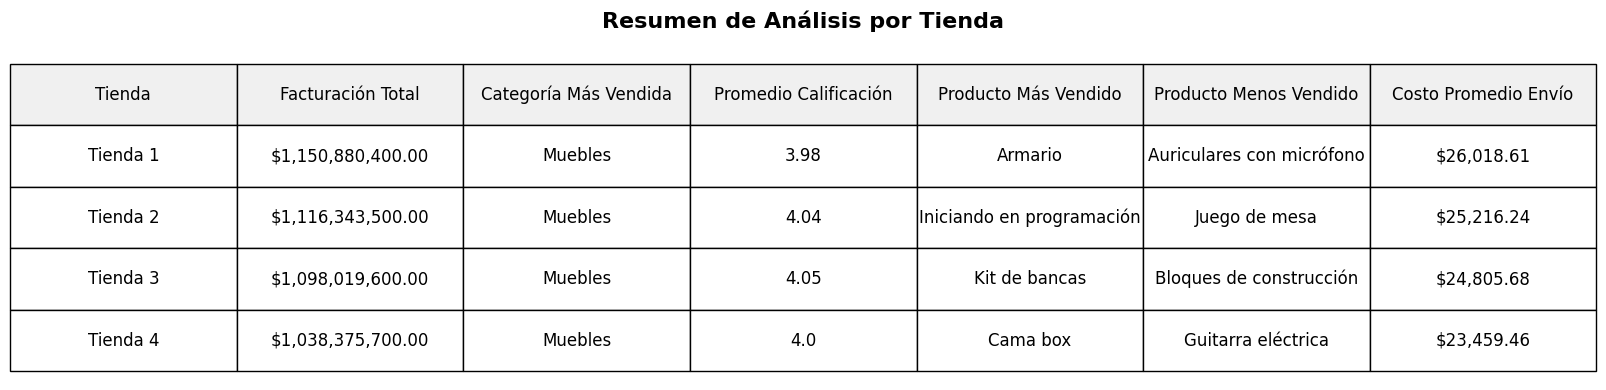

In [34]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

#print(tienda.head())



def analizar_tienda(df, nombre="Tienda"):
    df["cantidad"] = 1
    df["facturacion"] = df["Precio"] * df["cantidad"]

    facturacion_total = df["facturacion"].sum()
    categoria_top = df.groupby("Categoría del Producto")["cantidad"].sum().idxmax()
    promedio_calificacion = round(df["Calificación"].mean(),2)
    producto_mas_vendido = df.groupby("Producto")["cantidad"].sum().idxmax()
    producto_menos_vendido = df.groupby("Producto")["cantidad"].sum().idxmin()
    costo_prom_envio = round(df["Costo de envío"].mean(),2)

    return {
        "Tienda": nombre,
        "Facturación Total": facturacion_total,
        "Categoría Más Vendida": categoria_top,
        "Promedio Calificación": promedio_calificacion,
        "Producto Más Vendido": producto_mas_vendido,
        "Producto Menos Vendido": producto_menos_vendido,
        "Costo Promedio Envío": costo_prom_envio
    }

resultados = []

resultados.append(analizar_tienda(tienda, "Tienda 1"))
resultados.append(analizar_tienda(tienda2, "Tienda 2"))
resultados.append(analizar_tienda(tienda3, "Tienda 3"))
resultados.append(analizar_tienda(tienda4, "Tienda 4"))
#print(resultados)

resumen_df = pd.DataFrame(resultados)
resumen_df["Facturación Total"] = resumen_df["Facturación Total"].apply(lambda x: f"${x:,.2f}")

resumen_df["Costo Promedio Envío"] = resumen_df["Costo Promedio Envío"].apply(lambda x: f"${x:,.2f}")
resumen_df.to_csv("resumen_tiendas.csv", index=False)

print(resumen_df)

import matplotlib.pyplot as plt

# Crear figura
fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')  # Ocultar ejes

# Encabezados
columnas = [
    "Tienda",
    "Facturación Total",
    "Categoría Más Vendida",
    "Promedio Calificación",
    "Producto Más Vendido",
    "Producto Menos Vendido",
    "Costo Promedio Envío"
]

# Crear tabla
tabla = ax.table(
    cellText=resumen_df.values,
    colLabels=columnas,
    cellLoc='center',
    loc='center',
    colColours=["#f0f0f0"] * len(columnas)
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(12)
tabla.scale(1.2, 3.5)

plt.title("Resumen de Análisis por Tienda", fontsize=16, weight='bold', pad=20)
plt.tight_layout()
plt.show()

fig.savefig("resumen_tiendas.png", dpi=300)
